In [26]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path


cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper_plots.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt

# Set global Seaborn style
%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from common.consts import res_colors
from common.utils import collect_df, mfpt_table_from_samples
from common.hlda_utils import load_lambda_grid
from common.plot_utils import scatter_with_labels, add_linear_fit

data_dir = repo_root / "data"
mfpt_default_pkl = data_dir / "mfpt_samples_pace25000_ref.pkl"
tm_csv = data_dir / "Tm.csv"
lambda_cache = data_dir / "hlda_lambda_grid.pkl"


with open(mfpt_default_pkl, "rb") as f:
    mfpt_all = pickle.load(f)

mfpt_thresholds = sorted({float(k) for v in mfpt_all.values() for k in v.keys()})



tm = pd.read_csv(tm_csv, index_col="Mutant")
tm["Tm"] = pd.to_numeric(tm["Tm"], errors="coerce")
tm["abs_dTm"] = abs(tm["Tm"] - tm.loc["WT", "Tm"])

lambda_grid = load_lambda_grid(cache_path=lambda_cache, base_dir=data_dir / "hlda_trajectories", force=False)
lambda_grid.head()


,Mutant,tF,tU,lambda,nF,nU,var_F_diag,var_U_diag,weights,res_weights
0,D2A,0.18,0.30,6544.396562,8861,91951,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021822002644914233, 0.034387766655950155, 0...","{'d03': 69.03, 'd04': -203.82, 'd05': 244.86, ...","[656.43, 466.42, 480.73, 216.16, 670.73, 519.5..."
1,D2A,0.18,0.35,6628.341806,8861,91356,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021914678202689043, 0.034590364267731204, 0...","{'d03': 69.14, 'd04': -203.82, 'd05': 244.76, ...","[656.43, 466.47, 480.8, 216.07, 670.88, 519.33..."
2,D2A,0.18,0.41,7049.056425,8861,88358,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022499551728532702, 0.03570512795072451, 0....","{'d03': 71.37, 'd04': -203.64, 'd05': 242.67, ...","[654.7, 465.52, 480.32, 217.01, 671.25, 515.24..."
3,D2A,0.18,0.46,7366.079490,8861,86336,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022895281380262797, 0.03646222800497214, 0....","{'d03': 71.9, 'd04': -199.12, 'd05': 248.8, 'd...","[687.62, 467.04, 491.23, 216.11, 680.94, 525.8..."
4,D2A,0.18,0.52,7544.218118,8861,84109,"[0.0008478472743267516, 0.0011329781051374278,...","[0.023076225309800618, 0.036911968254067555, 0...","{'d03': 72.42, 'd04': -199.24, 'd05': 248.21, ...","[686.29, 467.89, 492.01, 216.01, 682.09, 524.8..."


In [28]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap="rocket_r"):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading="flat"
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha="center", va="center", fontsize=6)

    ax.set_xlabel("Unfolded RMSD threshold (tU)")
    ax.set_ylabel("Folded RMSD threshold (tF)")
    return im


def add_wt_point(ax, lambda_df, tF, tU):
    wt_rows = lambda_df[(lambda_df["Mutant"] == "WT") & np.isclose(lambda_df["tF"], tF) & np.isclose(lambda_df["tU"], tU)]
    if wt_rows.empty:
        return
    x_wt = float(wt_rows["lambda"].iloc[0])
    ax.scatter([x_wt], [0.0], s=90, marker="*", color="red", edgecolor="black", zorder=5)
    y_min, y_max = ax.get_ylim()
    dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
    ax.text(x_wt, dy, "WT", ha="center", va="bottom", fontsize=8, color="red", weight="bold")


def scatter_with_labels_ax(ax, df, x_col, y_col, label_col, title, xlab, ylab, rho, tF, tU, add_wt=True, corr_label="|ρ|"):
    if not df.empty:
        scatter_with_labels(
            ax,
            df,
            x_col,
            y_col,
            label_col=label_col,
            color_col="residue_idx",
            colors=res_colors,
            s=40,
            edgecolor="k",
            linewidth=0.6,
            alpha=0.85,
            annotate=True,
        )

    if add_wt:
        add_wt_point(ax, lambda_grid, tF, tU)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)


def mfpt_table_to_log_ratio(df_raw):
    if "Mutant" not in df_raw.columns:
        df = df_raw.rename_axis("Mutant").reset_index()
    else:
        df = df_raw.copy()
    df["Mutant"] = df["Mutant"].astype(str).str.strip()
    df["MFPT"] = df["mfpt"] / 1e6
    mfpt_wt = df.loc[df["Mutant"] == "WT", "MFPT"].iloc[0]
    df["log_mfpt_ratio"] = np.log(mfpt_wt / df["MFPT"])
    return df[["Mutant", "log_mfpt_ratio"]]


[954.7, 262.64, 224.42, 414.99, 514.71, 434.88, 329.64, 145.33, 174.13, 1200.8]


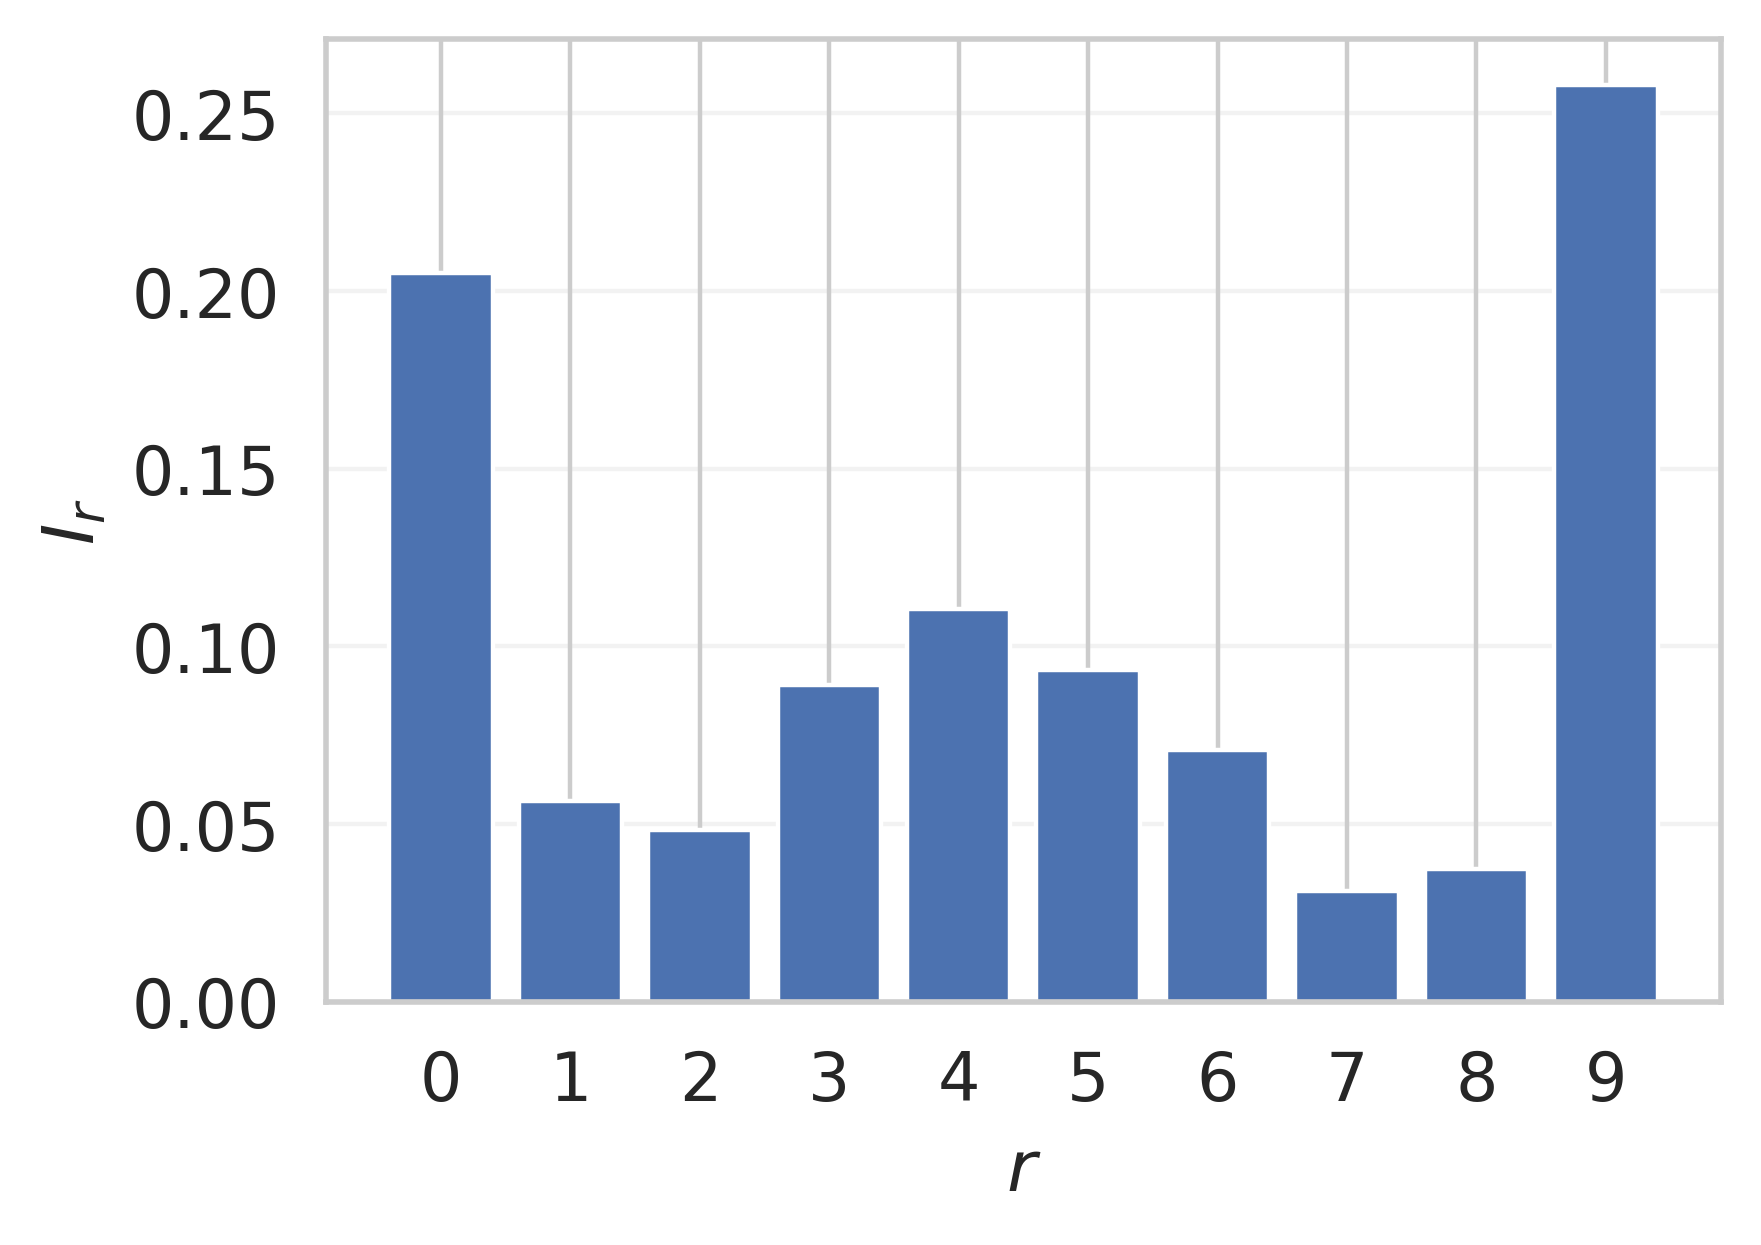

In [29]:
tF = 0.25
tU = 0.57

wt_row = lambda_grid[(lambda_grid['Mutant'] == 'WT') & (lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
res_weights = wt_row.iloc[0]['res_weights']

print(res_weights)
fig, ax = plt.subplots(figsize=(4.5, 3.2), dpi=200)
ax.bar(list(range(len(res_weights))), res_weights / np.sum(res_weights), color='#4C72B0')
ax.set_xlabel('$r$', fontsize=13)
ax.set_ylabel('$I_r$', fontsize=13)
ax.set_xticks(list(range(0, 10)))
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


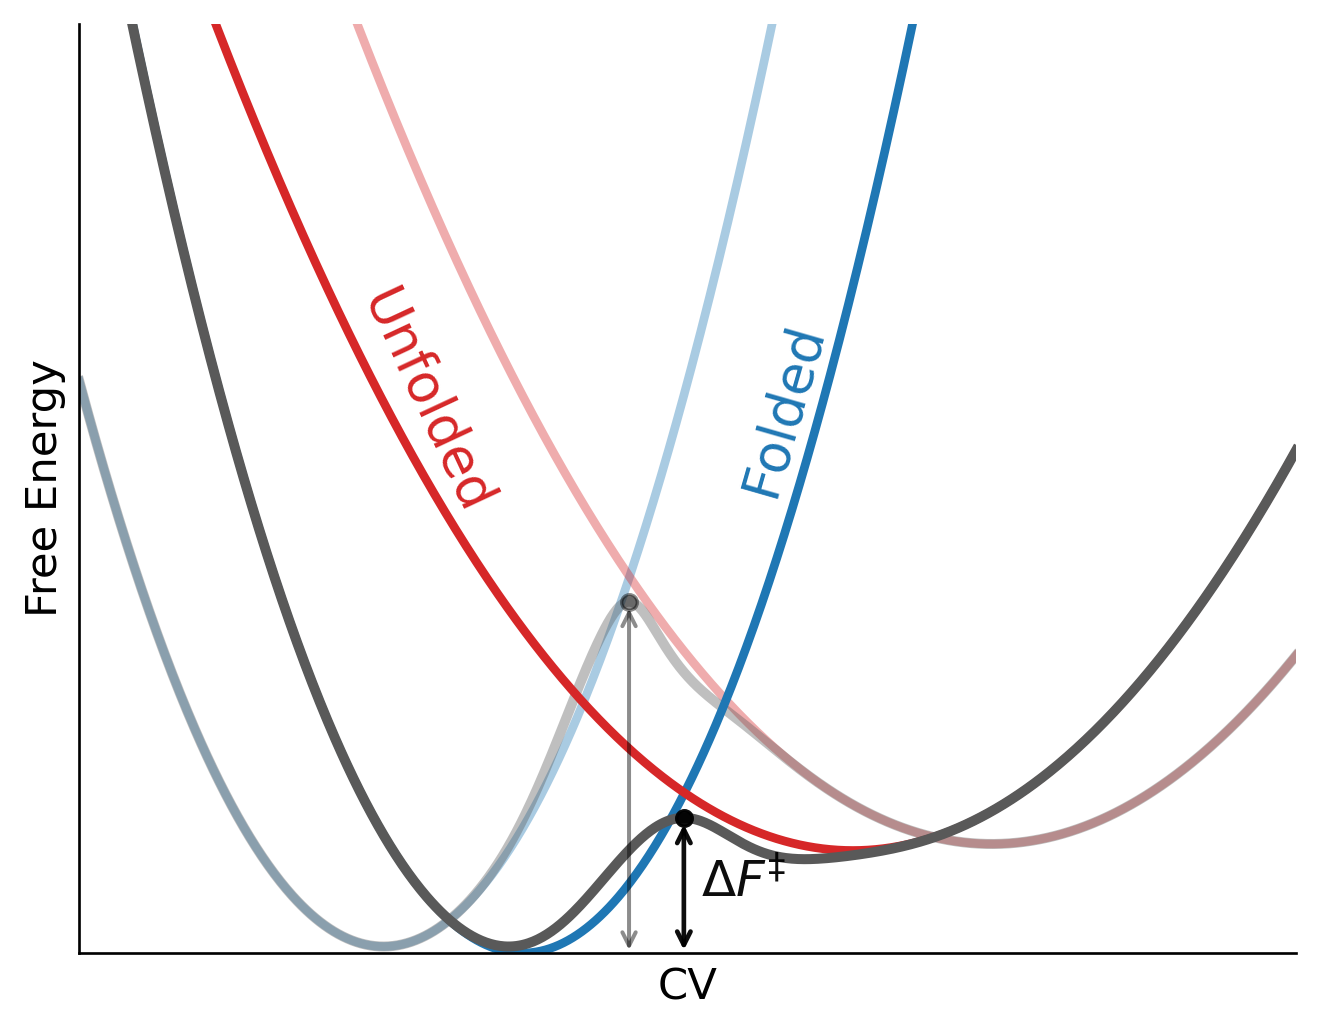

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def well(x, x0=0.0, k=1.0, offset=0.0):
    return 0.5 * k * (x - x0) ** 2 + offset

def fes_mix_logsumexp(F1, F2, beta=3.0):
    m = np.minimum(F1, F2)
    return m - (1.0 / beta) * np.log(np.exp(-beta * (F1 - m)) + np.exp(-beta * (F2 - m)))

def style_axis(ax):
    ax.set_xlabel("CV", fontsize=13)
    ax.set_ylabel("Free Energy", fontsize=13)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

def intersection_index(x, F1, F2):
    return int(np.argmin(np.abs(F1 - F2)))

def fes_peak_at_intersection(x, F1, F2, beta=3.0, sigma=0.35, delta_under=0.12):
    F_base = fes_mix_logsumexp(F1, F2, beta=beta)

    i_star = intersection_index(x, F1, F2)
    x_star = x[i_star]
    E_int = 0.5 * (F1[i_star] + F2[i_star])

    g = np.exp(-0.5 * ((x - x_star) / sigma) ** 2)

    dFdx = np.gradient(F_base, x)
    B = -dFdx[i_star]

    target_peak = E_int - delta_under
    A = target_peak - F_base[i_star]

    F = F_base + A * g + B * (x - x_star) * g

    for _ in range(3):
        d2 = np.gradient(np.gradient(F, x), x)
        if d2[i_star] < 0:
            break
        A += 0.05
        F = F_base + A * g + B * (x - x_star) * g

    return F, i_star

def add_barrier_height_arrow_at_index(
    ax, x, Fmix, i_top, label=r"$\Delta F^{\ddagger}$",
    x_text_shift=0.10, lw=1.5, alpha=1.0, text_alpha=1.0
):
    xb = x[i_top]
    yb = Fmix[i_top]
    y0 = np.min(Fmix)

    ax.annotate(
        "",
        xy=(xb, yb),
        xytext=(xb, y0 - 0.05),
        arrowprops=dict(arrowstyle="<->", lw=lw, color="black", alpha=alpha),
        zorder=6,
    )
    ax.scatter([xb], [yb], s=22, color="black", alpha=alpha, zorder=7)
    ax.text(
        xb + x_text_shift, 0.5 * (y0 + yb), label,
        va="center", fontsize=15, alpha=text_alpha
    )

# ---------- x-grid ----------
x = np.linspace(-3.5, 3.5, 800)

# Shared curvature / offsets
kF = 1.8
kU = 0.6
oF = 0.0
oU = 0.5

delta_under = 0.12
sigma_left  = 0.40
sigma_right = 0.28

# ---------- LOWER eigenvalue landscape (base / visible one) ----------
left = dict(xF=-0.95, xU=+0.95, beta=3.2)
F_fold_left = well(x, left["xF"], kF, oF)
F_unf_left  = well(x, left["xU"], kU, oU)
F_mix_left, i_peak_left = fes_peak_at_intersection(
    x, F_fold_left, F_unf_left,
    beta=left["beta"], sigma=sigma_left, delta_under=delta_under
)

# ---------- HIGHER eigenvalue landscape (overlay) ----------
right = dict(xF=-1.75, xU=+1.75, beta=4.8)
F_fold_right = well(x, right["xF"], kF, oF)
F_unf_right  = well(x, right["xU"], kU, oU)
F_mix_right, i_peak_right = fes_peak_at_intersection(
    x, F_fold_right, F_unf_right,
    beta=right["beta"], sigma=sigma_right, delta_under=delta_under
)

# ---------- shift minima near zero ----------
shift_left = np.min(F_mix_left) - 0.03
F_fold_left -= shift_left
F_unf_left  -= shift_left
F_mix_left  -= shift_left

shift_right = np.min(F_mix_right) - 0.03
F_fold_right -= shift_right
F_unf_right  -= shift_right
F_mix_right  -= shift_right

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(5.6, 4.4), dpi=240)

# base landscape
ax.plot(x, F_fold_left, lw=2.6, color="#1f77b4", zorder=2)
ax.plot(x, F_unf_left,  lw=2.6, color="#d62728", zorder=2)
ax.plot(x, F_mix_left,  lw=3.0, color="0.35", zorder=3)

# overlay landscape (higher eigenvalue) with lower opacity
overlay_alpha = 0.38
ax.plot(x, F_fold_right, lw=2.6, color="#1f77b4", alpha=overlay_alpha, zorder=1)
ax.plot(x, F_unf_right,  lw=2.6, color="#d62728", alpha=overlay_alpha, zorder=1)
ax.plot(x, F_mix_right,  lw=3.0, color="0.35", alpha=overlay_alpha, zorder=1)

style_axis(ax)

# state labels only for the base landscape
ax.text(
    0.55, 2.2, "Folded",
    color="#1f77b4", ha="center", va="bottom", fontsize=16,
    rotation=74
)

ax.text(
    -1.51, 2.1, "Unfolded",
    color="#d62728", ha="center", va="bottom", fontsize=16,
    rotation=-65
)

# # barrier arrows
add_barrier_height_arrow_at_index(
    ax, x, F_mix_left, i_peak_left,
    label=r"$\Delta F^{\ddagger}$",
    x_text_shift=0.10, lw=1.4, alpha=0.95, text_alpha=0.95
)

add_barrier_height_arrow_at_index(
    ax, x, F_mix_right, i_peak_right,
    label=r"",
    x_text_shift=0.16, lw=1.2, alpha=0.45, text_alpha=0.45
)

# middle direction arrow + text
# ax.annotate(
#     "",
#     xy=(0.77, 0.88),
#     xytext=(0.48, 0.88),
#     xycoords="axes fraction",
#     textcoords="axes fraction",
#     arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
#     annotation_clip=False,
# )

# ax.text(
#     0.625, 0.90, "Higher HLDA eigenvalue",
#     transform=ax.transAxes, ha="center", va="bottom", fontsize=13
# )

# limits
ymax = max(F_mix_left.max(), F_mix_right.max()) * 0.78
ax.set_ylim(0.0, ymax)
ax.set_xlim(x.min(), x.max())

plt.tight_layout()
plt.show()